In [1]:
pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\aitel\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration de l'affichage
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# EDA

In [3]:
# On précise que 'NA' et les chaînes vides doivent être considérés comme des valeurs manquantes
train = pd.read_csv('train.csv', na_values=['NA', '', ' '])
test = pd.read_csv('test.csv', na_values=['NA', '', ' '])

print(f"Dimensions train set : {train.shape}")
print(f"Dimensions test set : {test.shape}")

Dimensions train set : (104998, 12)
Dimensions test set : (45002, 11)


In [4]:
display(train.head())

train.info()

display(train.describe())

,ID,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,TARGET
0,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000,1
1,2,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000,0
2,3,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000,0
3,4,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000,0
4,5,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104998 entries, 0 to 104997
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      104998 non-null  int64  
 1   var1    104998 non-null  float64
 2   var2    104998 non-null  int64  
 3   var3    104998 non-null  int64  
 4   var4    104998 non-null  float64
 5   var5    84226 non-null   float64
 6   var6    104998 non-null  int64  
 7   var7    104998 non-null  int64  
 8   var8    104998 non-null  int64  
 9   var9    104998 non-null  int64  
 10  var10   102238 non-null  float64
 11  TARGET  104998 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 9.6 MB


,ID,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,TARGET
count,104998.0000,104998.0000,104998.0000,104998.0000,104998.0000,84226.0000,104998.0000,104998.0000,104998.0000,104998.0000,102238.0000,104998.0000
mean,52499.5000,6.0732,52.2610,0.4227,354.6279,6636.7387,8.4423,0.2684,1.0187,0.2422,0.7580,0.0667
std,30310.4561,257.8596,14.7690,4.2214,2104.7030,13594.9297,5.1363,4.1977,1.1344,4.1844,1.1162,0.2495
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,26250.2500,0.0300,41.0000,0.0000,0.1751,3400.0000,5.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,52499.5000,0.1559,52.0000,0.0000,0.3662,5400.0000,8.0000,0.0000,1.0000,0.0000,0.0000,0.0000
75%,78748.7500,0.5619,63.0000,0.0000,0.8666,8228.0000,11.0000,0.0000,2.0000,0.0000,1.0000,0.0000
max,104998.0000,50708.0000,107.0000,98.0000,329664.0000,3008750.0000,58.0000,98.0000,54.0000,98.0000,20.0000,1.0000


#### Class imbalance

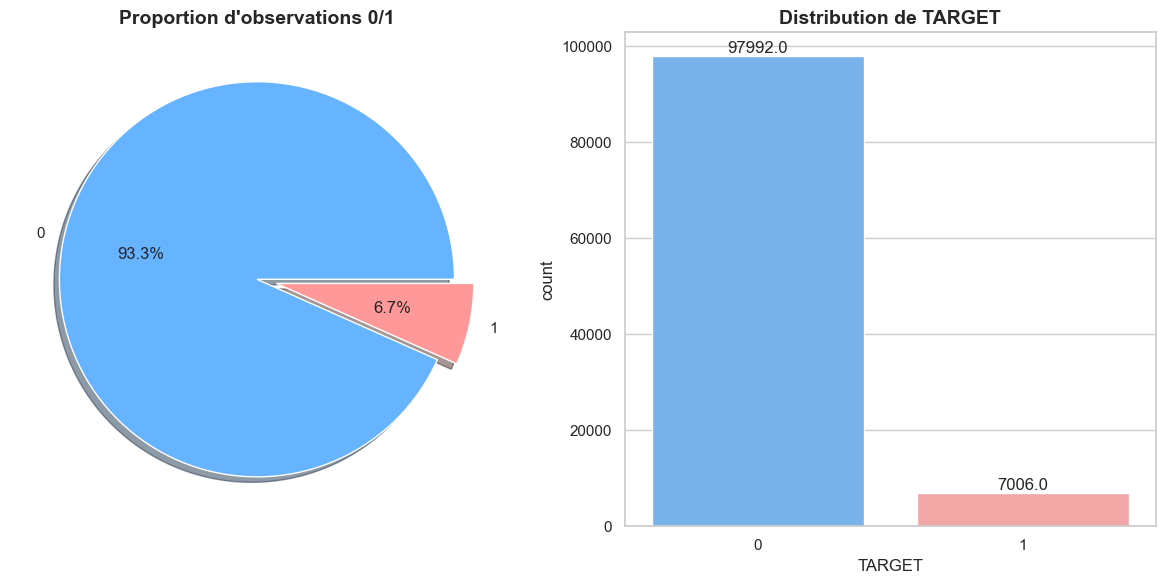

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

colors = ['#66b3ff', '#ff9999']

# Pie chart
train['TARGET'].value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%', 
    ax=axes[0], 
    shadow=True, 
    colors=colors
)
axes[0].set_title('Proportion d\'observations 0/1', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Countplot
sns.countplot(x='TARGET', data=train, ax=axes[1], palette=colors)
axes[1].set_title('Distribution de TARGET', fontsize=14, fontweight='bold')

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

L'analyse de notre variable cible révèle un déséquilibre de classes majeur : 93.3% des observations appartiennent à la classe majoritaire (0), contre seulement 6.7% pour la classe minoritaire (1). Dans le cadre d'une compétition évaluée sur la métrique RMSE, ce déséquilibre dicte notre stratégie de modélisation. La fonction de coût est définie par $\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$. Si nous prédisions des classes dures (0 ou 1), une erreur de classification sur la classe minoritaire générerait un résidu maximal de 1. Pour minimiser la variance de l'erreur, la stratégie mathématique optimale consiste à prédire des probabilités d'appartenance continues (entre 0 et 1).

Est-ce qu'on doit pour autant pallier l'absence d'équilibre avec du resampling ?

Non ! Pas de SMOTE, pour deux raisons assez simples: 
- la RMSE, notre métrique, va exploser si on change artificiellement le prior de distribution (si le modèle prédit des valeurs moyennes là où elles devraient être faibles). On laisse plutôt le modèle apprendre un calibrage naturel -> en s'appuyant sur la cross-validation.

*Note: Si nous étions évalués sur l'AUC ou le F1-Score (qui évaluent le classement ou la capacité à séparer les classes), le sampling ou l'utilisation de poids (scale_pos_weight) serait utile.*

- l'ajout de variables dans l'étape de feature engineering donnera au modèle l'expressivité nécessaire


TLDR

- Constat visuel : Fort déséquilibre de la Target (ratio ~14:1).

- Impact métrique : La RMSE pénalise fortement les erreurs absolues de 1 (cas d'une mauvaise prédiction binaire pure).

- Décision stratégique : Nos modèles devront obligatoirement cracher des probabilités continues pour lisser l'erreur et optimiser le score.

### Missing values

In [6]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    if mis_val.sum() == 0:
        return 'No missing values'
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Valeurs Manquantes', 1 : '% du Total'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% du Total', ascending=False).round(1)
    return mis_val_table_ren_columns

print("--- Valeurs manquantes dans le train set ---")
display(missing_values_table(train))

print("\n--- Valeurs manquantes dans le test set ---")
display(missing_values_table(test))

--- Valeurs manquantes dans le train set ---


,Valeurs Manquantes,% du Total
var5,20772,19.8000
var10,2760,2.6000



--- Valeurs manquantes dans le test set ---


,Valeurs Manquantes,% du Total
var5,8959,19.9000
var10,1164,2.6000


Le diagnostic des valeurs manquantes isole deux variables : var5 et var10. Le cas de var5 est particulièrement critique avec un volume de données manquantes avoisinant les 20%. D'un point de vue statistique, amputer le dataset d'un cinquième de ses observations introduirait un biais de sélection inacceptable. De plus, nous postulons que cette absence d'information n'est pas aléatoire (phénomène MNAR - Missing Not At Random) : le fait même que la valeur soit manquante contient potentiellement un signal prédictif par rapport à notre Target.
Stratégie retenue : Extraction de ce signal via la création d'une variable booléenne (is_var5_missing), suivie d'une stratégie d'imputation adaptée aux algorithmes choisis.

- Diagnostic : Concentration des NaN sur var5 (~20%) et var10.

- Hypothèse statistique : Mécanisme MNAR suspecté. L'absence de la donnée est en soi une information.

- Conservation des lignes, isolation du signal de "manque" via des indicateurs binaires, puis imputation.

### Boxplots

ValueError: num must be an integer with 1 <= num <= 12, not 13

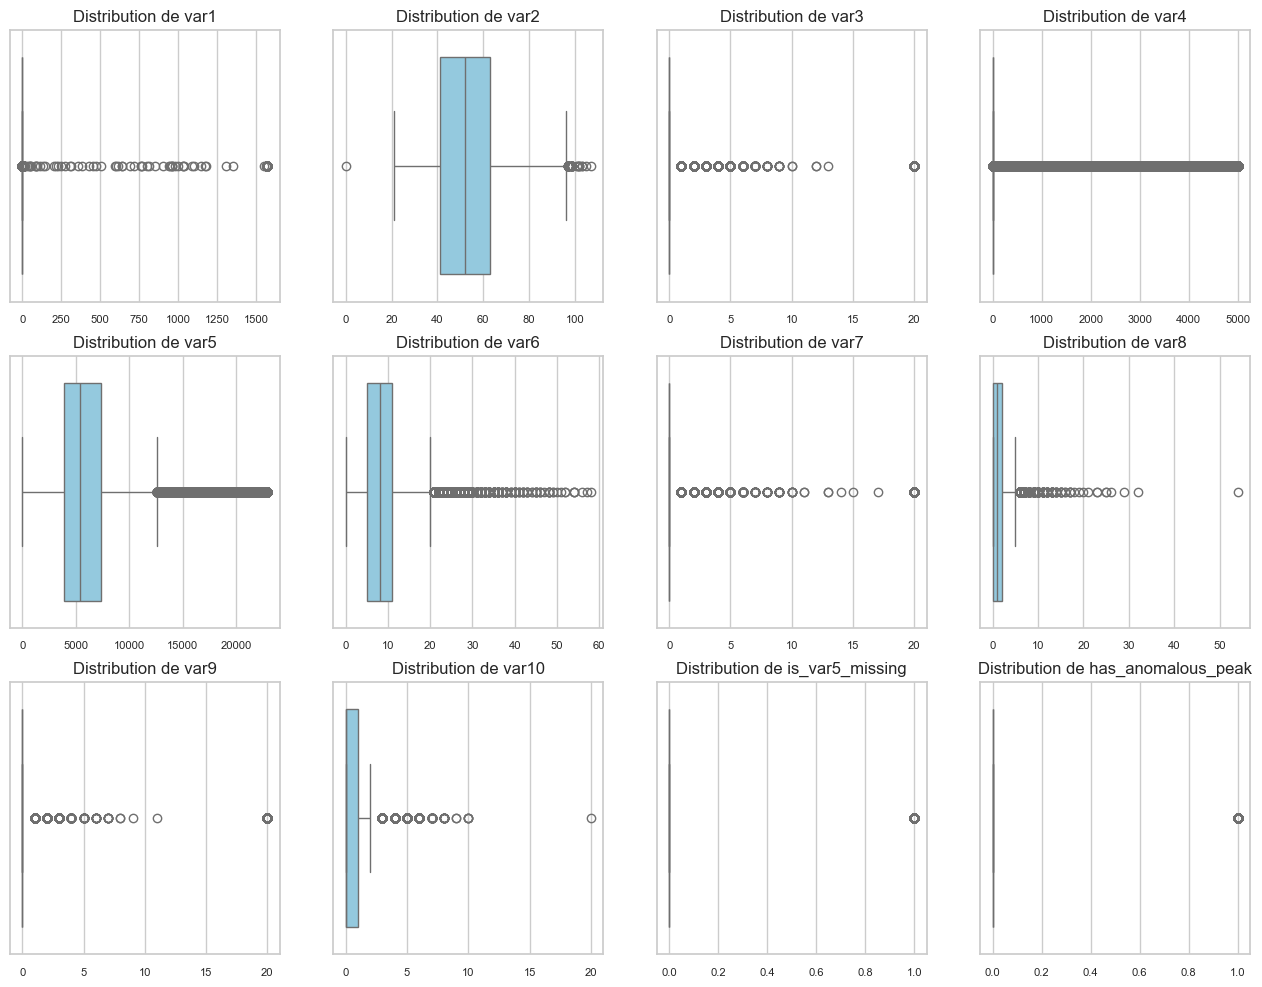

: 

In [ ]:
# On exclut l'ID et la TARGET qui ne sont pas des features continues
features =[col for col in train.columns if col not in ['ID', 'TARGET']]

plt.figure(figsize=(16, 12))
for i, col in enumerate(features, 1):
    plt.subplot(3, 4, i)
    # On utilise un boxplot horizontal, souvent plus lisible pour les grandes valeurs
    sns.boxplot(x=train[col], color='skyblue') 
    plt.title(f'Distribution de {col}', fontsize=12)
    plt.xlabel('')

plt.tight_layout()
plt.show()



L'analyse de dispersion par boxplots met en évidence une structure de données fortement asymétrique. À l'exception de var2 qui présente une boîte interquartile (IQR) visible et centrée, la majorité des variables (var1, var3, var4, var7, var9) subissent une compression extrême de leur IQR à gauche de l'axe, écrasée par la présence d'outliers massifs.
L'analyse visuelle permet de scinder ces valeurs extrêmes en deux comportements topologiques distincts :

- Etirement continu : Des variables (ex: var1, var4) montrent une longue traîne de valeurs continues s'étirant vers des dizaines de milliers. Cela indique une distribution de type loi de puissance. L'utilisation de modèles linéaires est compromise ; nous privilégierons des modèles ensemblistes basés sur des arbres, naturellement robustes à la monotonie de ces échelles.

- Anomalie discrète : Sur var3, var7 et var9, on observe une anomalie structurelle : des amas de points isolés en bout de distribution, concentrés spécifiquement autour des valeurs 96 et 98. Statistiquement, l'apparition de tels pics de densité sur des valeurs entières isolées aux extrémités suggère fortement des artefacts de collecte ou des codes d'erreur système (valeurs refuges). Un traitement spécifique en feature engineering s'impose.

TLDR 

- Asymétrie globale : Écrasement des distributions vers 0, forte "right-skewness".

- Impact modèle : Ce profil de distribution disqualifie les régressions linéaires classiques au profit des modèles d'arbres de décision.

- Découverte majeure : Identification d'un "comportement de palier" sur var3, var7 et var9 (amas de valeurs sur 96 et 98). Hypothèse forte de codes d'erreur à isoler.

### Analyse de la cardinalité

In [8]:
print("Cardinalité des variables :")
display(train[features].nunique().sort_values())

Cardinalité des variables :


var10       12
var9        13
var3        15
var7        18
var8        28
var6        57
var2        85
var5     12038
var4     82416
var1     88523
dtype: int64

L'analyse de la cardinalité (le nombre de valeurs distinctes par variable) confirme notre hypothèse visuelle issue des boxplots. Des variables comme var3, var7 et var9 possèdent une cardinalité extrêmement faible (moins de 50 valeurs uniques) par rapport à la taille du dataset (plus de 100 000 lignes). Bien qu'elles soient encodées numériquement, elles se comportent statistiquement comme des variables discrètes ou catégorielles ordinales.

### Zoom sur les anomalies

In [9]:
mask_anomalie = train['var3'].isin([96, 98])
taux_global = train['TARGET'].mean() * 100
taux_anomalie = train[mask_anomalie]['TARGET'].mean() * 100

print(f"Taux de classe 1 global : {taux_global:.2f}%")
print(f"Taux de classe 1 si var3 vaut 96 ou 98 : {taux_anomalie:.2f}%")

Taux de classe 1 global : 6.67%
Taux de classe 1 si var3 vaut 96 ou 98 : 52.36%


En isolant les individus présentant les valeurs extrêmes "96" et "98" sur var3, on observe un saut conséquent de la probabilité d'appartenir à la classe 1 (Target). Cette différence statistique massive prouve que ces valeurs ne sont pas de simples outliers continus, mais un signal d'alerte fort qui devra être isolé par une variable binaire lors du feature engineering.

### Skewness via KDE

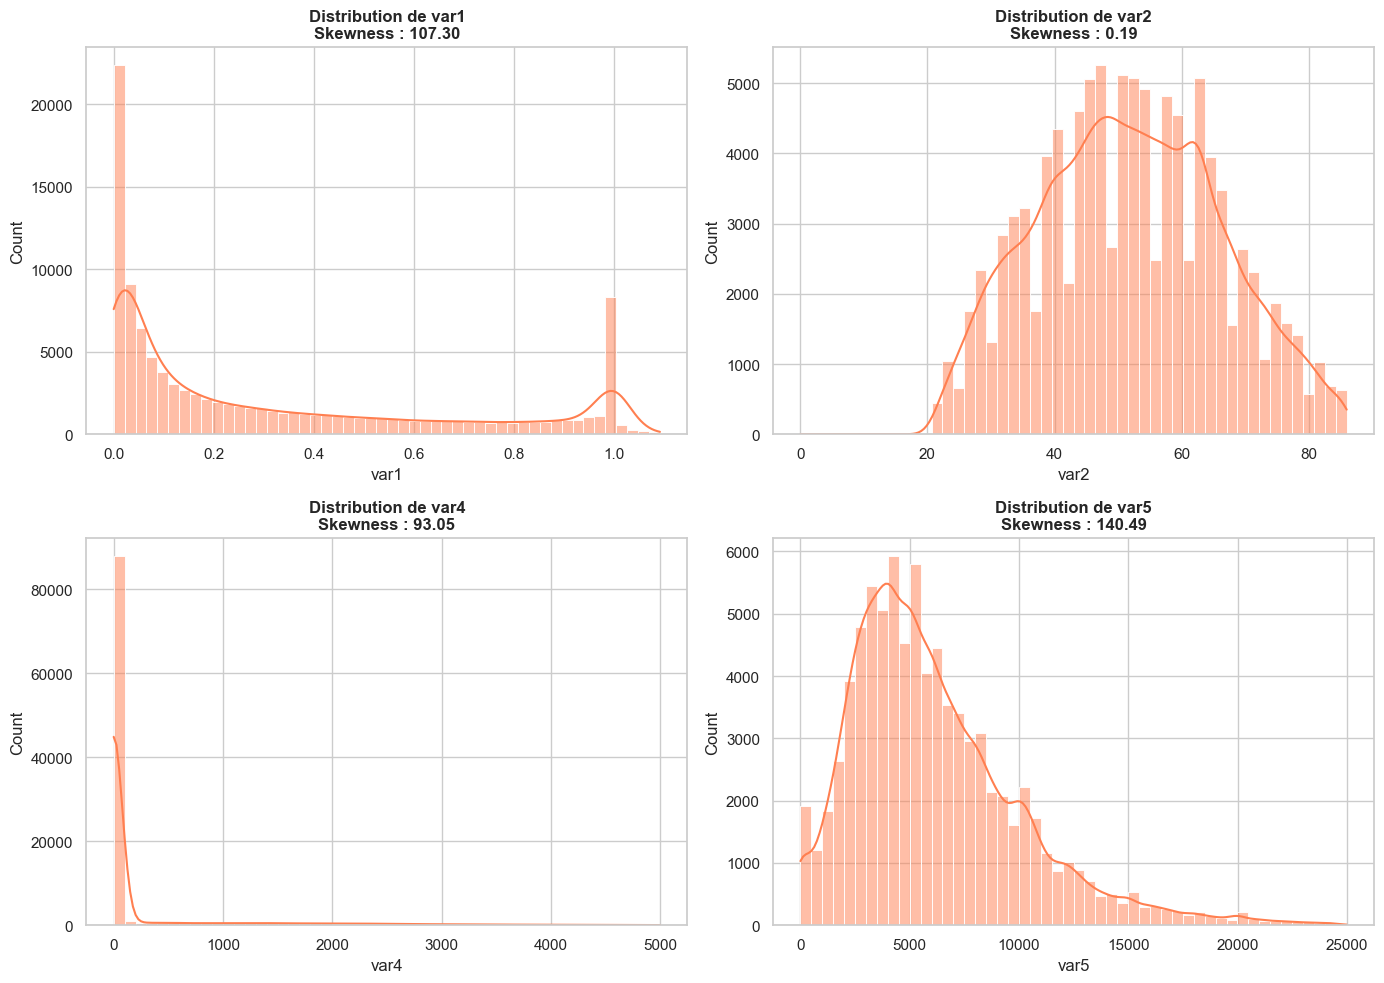

In [10]:
vars_to_plot = ['var1', 'var2', 'var4', 'var5']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    # On filtre les 1% des valeurs les plus extrêmes pour voir la cloche principale
    q99 = train[col].quantile(0.99)
    sns.histplot(train[train[col] < q99][col], kde=True, ax=axes[i], color='coral', bins=50)
    
    # coefficient de skewness
    skew_val = train[col].skew()
    axes[i].set_title(f'Distribution de {col}\nSkewness : {skew_val:.2f}', fontweight='bold')

plt.tight_layout()
plt.show()

Le coefficient d'asymétrie (Skewness) quantifie la déformation d'une distribution par rapport à une loi Normale (Skewness = 0). L'analyse des distributions (KDE) met en évidence deux familles de variables structurellement opposées.
D'un côté, var2 présente une distribution bornée en cloche quasi-normale, avec un Skewness très faible de 0.19. C'est la signature statistique classique d'une caractéristique intrinsèque à variance modérée.

De l'autre, var1, var4 et var5 affichent une asymétrie extrême à droite (Right-skewed), avec des scores de Skewness dépassant les 90 (jusqu'à 140.49 pour var5). Ce comportement suit une loi de puissance (Power Law), typique des variables de cumul ou de magnitude non bornées. 

Régression linéaire: nécessite impérativement une transformation logarithmique pour lisser ces queues de distribution
Arbres de décision: invariants aux transformations monotones.

Faire la transformation (voir feature engineering ci-après) permet :
1. Lisser les gradients
2. L'ensembling 

### Analyse bivariée

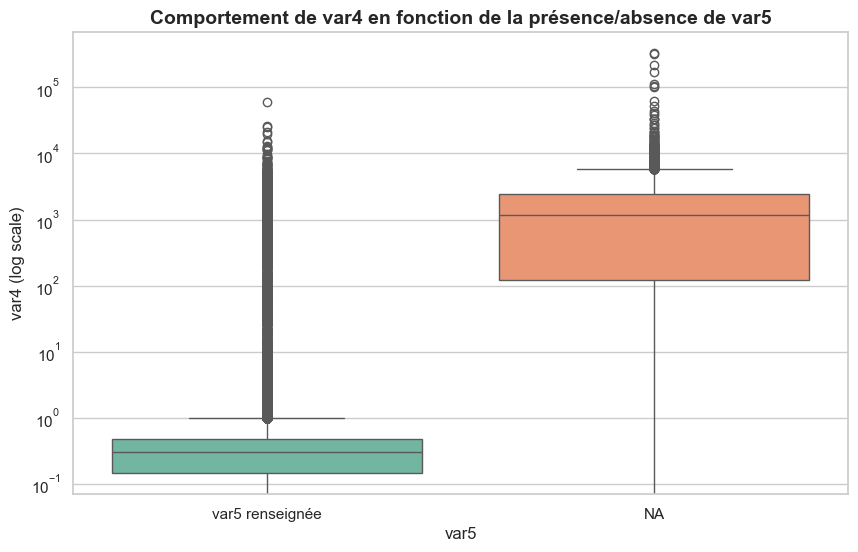

In [11]:
temp_df = train.copy()
temp_df['var5_is_missing'] = temp_df['var5'].isnull().map({True: 'NA', False: 'var5 renseignée'})

fig, ax = plt.subplots(figsize=(10, 6))

# On utilise une échelle logarithmique sur l'axe Y car var4 a des valeurs extrêmes
sns.boxplot(x='var5_is_missing', y='var4', data=temp_df, palette='Set2', ax=ax)
ax.set_yscale('log')
ax.set_title("Comportement de var4 en fonction de la présence/absence de var5", fontsize=14, fontweight='bold')
ax.set_ylabel("var4 (log scale)")
ax.set_xlabel("var5")

plt.show()

L'analyse bivariée confirme notre hypothèse MNAR sur var5 et révèle un décalage structurel majeur (Covariate Shift). En isolant la distribution de var4 selon la présence ou l'absence de var5, on observe un saut de plusieurs ordres de grandeur sur l'axe logarithmique.
Lorsque var5 est renseignée, les valeurs de var4 sont concentrées à des échelles très basses (la médiane se situe en dessous de $10^0$). À l'inverse, lorsque var5 est absente (NA), la distribution de var4 est translatée vers le haut, avec un premier quartile dépassant les $10^2$. Statistiquement, cela signifie que l'absence de var5 modifie drastiquement l'échelle ou l'unité de mesure de var4. Créer un indicateur binaire de cette absence est donc indispensable pour informer le modèle de ce changement de référentiel.

TLDR

- Preuve visuelle du MNAR : Le graphique démontre que le manque dans var5 n'est pas un hasard.

- Observation du covariate shift : Saut de magnitude de var4 (de $<10^0$ à $>10^2$) selon le statut de var5.

- Impact direct sur le preprocessing : Création obligatoire d'une "meta-feature" booléenne pour guider les scissions des arbres.

### Matrice de corrélation de Spearman


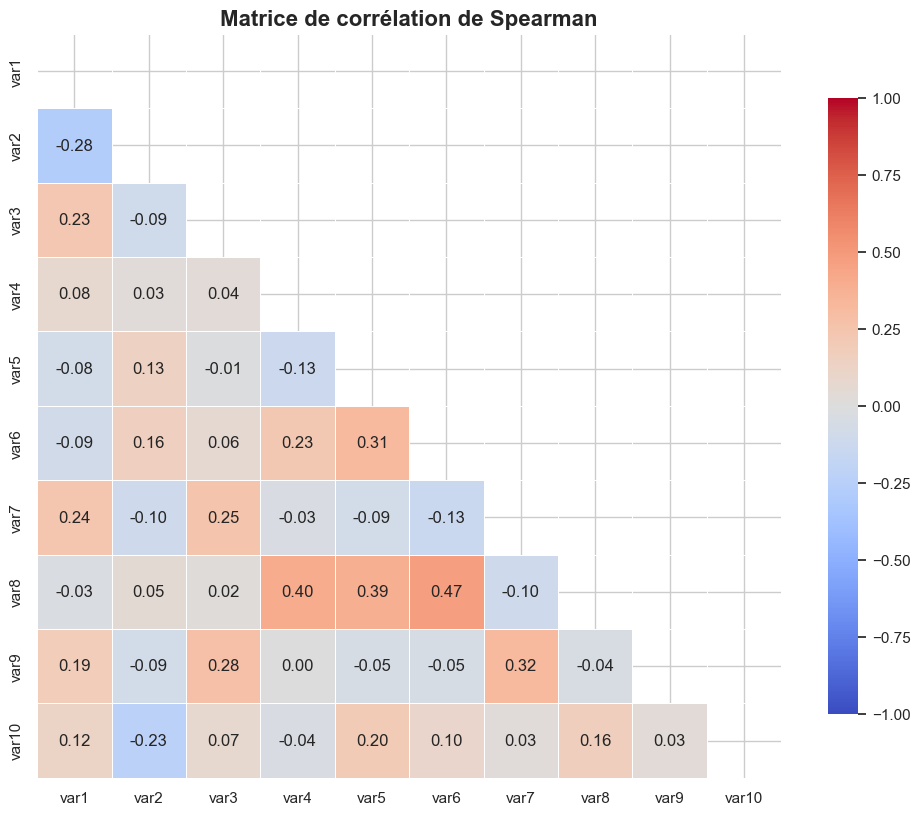

In [12]:
corr_matrix = train[features].corr(method='spearman')

# Création d'un masque pour ne cacher la partie supérieure (symétrique)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1, vmin=-1, 
    center=0,
    square=True, 
    linewidths=.5, 
    annot=True, 
    fmt=".2f", 
    cbar_kws={"shrink": .8}
)

plt.title("Matrice de corrélation de Spearman", fontsize=16, fontweight='bold')
plt.show()

Pour analyser la collinéarité tout en neutralisant l'effet des valeurs extrêmes précédemment identifiées, nous privilégions la corrélation de Spearman (basée sur les rangs). La matrice révèle une absence totale de collinéarité sévère : aucune corrélation ne dépasse le seuil critique de 0.8. Les corrélations positives les plus élevées s'observent entre var8 et les variables var6 (0.47) et var4 (0.40).
Il est intéressant de noter que des variables au comportement asymétrique similaire (comme var3, var7 et var9) ne corrèlent qu'à des niveaux modérés (ex: 0.32 entre var7 et var9). Cette apparente décorrélation s'explique par la méthode de Spearman elle-même : face à une écrasante majorité de valeurs strictement égales à 0 (ties), l'algorithme assigne un rang moyen, ce qui dilue mathématiquement la corrélation globale malgré des queues de distribution communes.

L'absence de redondance pure nous permet de conserver l'intégralité des variables pour la modélisation.

TLDR

- Choix de la méthode : Spearman sélectionné spécifiquement pour sa robustesse face aux distributions asymétriques observées.

- Résultat clé : Aucune collinéarité dangereuse (> 0.8) ne nécessitant une suppression de variable.

- Nuance statistique: Expliquer brièvement comment la surreprésentation des zéros "lisse" les coefficients de rang.

# Preprocessing

### Handling missing values + creating flags

In [13]:
datasets = [train, test]

for df in datasets:
    # Création du Flag pour var5 manquant
    df['is_var5_missing'] = df['var5'].isnull().astype(int)
    
    # Imputation par la médiane pour les valeurs manquantes
    # On utilise la médiane car la moyenne serait faussée par nos outliers extrêmes
    df['var5'] = df['var5'].fillna(df['var5'].median())
    df['var10'] = df['var10'].fillna(df['var10'].median())


display(missing_values_table(train))

display(missing_values_table(test))

'No missing values'

'No missing values'

Conformément à notre analyse de l'effet MNAR (Missing Not At Random), nous extrayons d'abord le signal de l'absence de donnée en créant un indicateur booléen is_var5_missing.

Une fois cette information sauvegardée, nous devons imputer les valeurs manquantes de var5 et var10 pour garantir la compatibilité avec certains algorithmes (notamment les modèles linéaires si nous décidons d'utiliser l'ensembling). Face à l'asymétrie extrême (skewness > 140) et à la présence d'outliers massifs démontrées précédemment, l'imputation par la moyenne introduirait un biais sévère de surestimation. Nous optons donc rigoureusement pour l'imputation par la médiane, qui est une métrique de centralité robuste aux valeurs extrêmes.

TLDR

- Extraction du signal : Création d'un flag binaire pour var5 pour conserver l'information structurelle de son absence.

- Imputation par la médiane. La moyenne est trop sensible à la "skewness" extrême ; la médiane garantit une robustesse face aux lois de puissance du dataset.

### Traitement des outliers et capping

In [14]:
# Variables présentant des pics isolés anormaux (96 et 98) en bout de distribution
peak_vars = ['var3', 'var7', 'var9']

for df in datasets:
    # On crée une feature binaire pour indiquer que l'individu possède ce comportement anormal
    df['has_anomalous_peak'] = ((df['var3'] >= 96) | (df['var7'] >= 96) | (df['var9'] >= 96)).astype(int)
    
    # On ramène ces pics artificiels à une valeur maximale cohérente avec la distribution (ex: 20)
    for col in peak_vars:
        df.loc[df[col] >= 96, col] = 20

    # Capping des variables à très forte asymétrie droite
    # Calcul des percentiles sur le Train (avoid data leakage)
    cap_var1 = train['var1'].quantile(0.999) 
    cap_var4 = train['var4'].quantile(0.99)
    cap_var5 = train['var5'].quantile(0.99)

    df.loc[df['var1'] > cap_var1, 'var1'] = cap_var1
    df.loc[df['var4'] > cap_var4, 'var4'] = cap_var4
    df.loc[df['var5'] > cap_var5, 'var5'] = cap_var5


L'observation des distributions KDE et des boxplots a mis en lumière une anomalie topologique sur les variables var3, var7 et var9. La distribution continue s'arrête brutalement autour de 15-20, suivie d'un vide total, puis de pics isolés de forte densité exactement sur les entiers 96 et 98.
Statistiquement, l'apparition de tels amas aux extrémités est caractéristique de "flags" systèmes (des valeurs par défaut arbitraires insérées lors de la collecte). Si nous laissons ces valeurs en l'état, les algorithmes interpréteront la magnitude littéralement (un individu à 96 serait considéré mathématiquement comme 8 fois supérieur à un individu à 12), ce qui corromprait la fonction de coût.

1. Création d'une variable binaire has_anomalous_peak pour isoler ce comportement.

2. Remplacement de ces pics par un plafond logique (20) issu de l'observation de la distribution continue.

3. Capping (plafonnement) des variables continues extrêmes (var1, var4, var5) aux 99ème et 99.9ème percentiles. Crucial : Ces percentiles sont calculés exclusivement sur le Train set pour prévenir toute fuite de données (Data Leakage) vers le Test set.

TLDR

- Isolation des pics 96/98 via un flag binaire, puis rabattage à la limite de la distribution réelle (20).

- Capping: Écrêtage des longues traînes (Percentiles 99 et 99.9) pour stabiliser la variance.

- Calcul des seuils de capping uniquement sur le set d'entraînement pour éviter tout Data Leakage.

### Feature engineering

In [15]:
import numpy as np

base_vars = [f"var{i}" for i in range(1, 11)]

for df in datasets:
    # Agrégation des variables corrélées
    df['sum_var3_7_9'] = df['var3'] + df['var7'] + df['var9']
    
    # Création d'un ratio entre l'amplitude de var5 et la composante discrète var10
    df['ratio_var5_var10'] = df['var5'] / (df['var10'] + 1)

    # Interaction découverte lors de l'analyse bivariée
    # Le comportement de var4 change si var5 est absent
    df['interaction_var4_var5'] = df['var4'] * df['var5']
    
    # Statistiques par individu sur les variables de base
    df['feat_mean'] = df[base_vars].mean(axis=1)
    df['feat_std'] = df[base_vars].std(axis=1)
    df['feat_max'] = df[base_vars].max(axis=1)
    df['feat_min'] = df[base_vars].min(axis=1)
    df['feat_range'] = df['feat_max'] - df['feat_min']
    
    # Réduction de l'asymétrie
    # On utilise log1p (log(1+x)) car nos variables contiennent des zéros
    skewed_vars = [
        'var1',
        'var4',
        'var5',
        'ratio_var5_var10',
        'interaction_var4_var5'
    ]
    
    for col in skewed_vars:
        df[col + '_log'] = np.log1p(df[col])

print("Colonnes finales :")
print(train.columns.tolist())

Colonnes finales :
['ID', 'var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var7', 'var8', 'var9', 'var10', 'TARGET', 'is_var5_missing', 'has_anomalous_peak', 'sum_var3_7_9', 'ratio_var5_var10', 'interaction_var4_var5', 'feat_mean', 'feat_std', 'feat_max', 'feat_min', 'feat_range', 'var1_log', 'var4_log', 'var5_log', 'ratio_var5_var10_log', 'interaction_var4_var5_log']


Le feature engineering s'appuie directement sur les découvertes de notre EDA :

1. Consolidation du signal (sum_var3_7_9) : La matrice de corrélation (Spearman) et l'analyse de cardinalité ont révélé que ces trois variables partagent la même dynamique d'asymétrie et les mêmes anomalies de collecte. Elles mesurent empiriquement des occurrences d'une même famille d'événements. Leur sommation permet de réduire le bruit et de consolider le signal prédictif.

2. Ratio de densité (ratio_var5_var10) : var5 représente une magnitude continue très étalée, tandis que var10 agit comme un compteur discret (petits entiers). La création de ce ratio (Magnitude / Compteur) est une technique standard pour extraire une notion de "densité moyenne par entité" (ajout de +1 pour éviter une division par zéro).

3. Interaction de Covariate Shift : Le produit croisé interaction_var4_var5 est créé pour aider le modèle à capter la dépendance structurelle identifiée lors de l'analyse bivariée.

Transformation logarithmique (log1p) : Bien que nos modèles de prédilection (XGBoost, LightGBM) soient agnostiques à la distribution monotone des variables, nous appliquons une transformation logarithmique sur les variables à forte asymétrie. Cela nous permet de stabiliser les échelles de nos nouvelles features créées et laisse la porte ouverte à l'utilisation future de modèles linéaires pénalisés (Ridge/Lasso). Nous privilégions le log1p (log(1+x)) plutôt que la transformation de Box-Cox en raison de la prépondérance de valeurs nulles (zéros) dans le dataset, que Box-Cox gère difficilement sans translation artificielle.

TLDR

- Création de Méta-variables : Somme des variables 3, 7 et 9 pour consolider le signal d'un même phénomène statistique.

- Ratios de densité : Division d'une variable d'amplitude (var5) par une variable de comptage (var10) pour révéler des proportions cachées.

- Lissage des échelles : Application de log1p pour écraser les asymétries extrêmes (justifié par la forte présence de zéros face à Box-Cox) et préparer les données pour d'éventuels modèles d'ensemblage linéaires.

# Modélisation, Split, CV, & Baseline

**Sélection des modèles**

Bien que la compétition soit évaluée sur une métrique d'erreur continue (RMSE), la nature binaire de notre Target nous impose d'utiliser des modèles de Classification. L'astuce mathématique consiste à extraire la probabilité continue d'appartenir à la classe 1 (via .predict_proba()) plutôt que la classe dure (0 ou 1), ce qui permet de lisser l'erreur et de minimiser drastiquement la RMSE finale. Nous mettons en compétition trois algorithmes aux paradigmes distincts pour établir notre Baseline :

- Logistic Regression (Pénalité L2) : Notre modèle linéaire de référence. Il nécessite impérativement des données standardisées pour que sa régularisation s'applique uniformément sur tous les coefficients.

- LightGBM Classifier : Un modèle d'arbres décisionnels boostés (Gradient Boosting) réputé pour sa rapidité d'exécution, sa légèreté et sa grande efficacité sur les données tabulaires asymétriques.

- XGBoost Classifier : Le standard industriel historique, offrant une forte régularisation interne pour lutter contre le sur-apprentissage.

- CatBoost Classifier : Contrairement à LightGBM (qui pousse les feuilles de façon asymétrique là où il y a le plus d'erreur) et XGBoost (qui descend niveau par niveau), CatBoost force ses arbres à être parfaitement symétriques. Le même critère de coupure est appliqué sur tous les nœuds d'un même niveau.


*Note additionnelle*: Pourquoi Logistic plutôt que Ridge ? 
- Ridge = régression continue, donc nécessité de clip les probas entre 0 et 1
- la sigmoid écrase naturellement les probas dans cet intervalle

Séparation des ensembles (Split)

Avant toute modélisation, nous isolons notre variable cible (TARGET) de notre matrice de caractéristiques (X). L'ensemble de test officiel (dont nous conservons précieusement les identifiants ID pour la soumission finale sur Kaggle) est également isolé. Cette étape garantit une séparation stricte des environnements d'entraînement et de prédiction.

In [16]:
# Splitting

y = train['TARGET']
X = train.drop(['ID', 'TARGET'], axis=1)

# On isole le Test set (on garde les IDs de côté pour la soumission finale)
test_ids = test['ID']
X_test = test.drop(['ID'], axis=1)

print(f"Dimensions de X (train) : {X.shape}")
print(f"Dimensions de y (target) : {y.shape}")
print(f"Dimensions de X_test (test) : {X_test.shape}")

Dimensions de X (train) : (104998, 25)
Dimensions de y (target) : (104998,)
Dimensions de X_test (test) : (45002, 25)


CV et Standard scaling

Pour évaluer nos modèles de manière robuste, nous implémentons une fonction d'évaluation sur mesure intégrant deux mécanismes de sécurité majeurs :

- Stratified K-Fold (5 splits) : Face à notre déséquilibre de classes extrême (93% de 0 contre 7% de 1) , un découpage aléatoire standard risquerait de générer des folds de validation dépourvus de la classe minoritaire. Le Stratified K-Fold garantit que chaque sous-échantillon conserve l'exacte proportion de 7% de cas positifs, stabilisant ainsi la variance de notre RMSE et nous protégeant d'un shake-up au classement privé.

- Prévention du data leakage : Les modèles linéaires nécessitant une standardisation, il est crucial de ne pas appliquer le StandardScaler sur l'ensemble du jeu de données avant le découpage. Cela transmettrait des informations statistiques du jeu de validation vers le jeu d'entraînement. Notre code force le "fit" du scaler strictement à l'intérieur de la boucle, uniquement sur les données d'entraînement de chaque pli.

In [17]:
# Stratified K-Fold CV + scaling

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

def evaluate_model_cv(model, X_data, y_data, n_splits=5, is_linear=False):
    """
    Évalue un modèle avec un Stratified K-Fold et retourne la RMSE moyenne.
    Gère le scaling en interne pour éviter le Data Leakage.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    rmse_scores =[]
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
        X_train_fold, X_val_fold = X_data.iloc[train_idx].copy(), X_data.iloc[val_idx].copy()
        y_train_fold, y_val_fold = y_data.iloc[train_idx], y_data.iloc[val_idx]
        
        # Scaling à l'intérieur de la boucle
        if is_linear:
            scaler = StandardScaler()
            X_train_fold = scaler.fit_transform(X_train_fold)
            X_val_fold = scaler.transform(X_val_fold)
            
        model.fit(X_train_fold, y_train_fold)
        
        preds = model.predict_proba(X_val_fold)[:, 1]
        
        rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
        rmse_scores.append(rmse)
    
    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)
    
    print(f"Avg RMSE (5-Folds) : {mean_rmse:.5f} (+/- {std_rmse:.5f})")
    return mean_rmse, rmse_scores

## Baseline

In [18]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


models = {
    # Linear
    "Logistic Regression (L2)": LogisticRegression(max_iter=1000, random_state=42),
    
    # DT
    "LightGBM Classifier": LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
    "XGBoost Classifier": XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss'),
    "CatBoost Classifier": CatBoostClassifier(n_estimators=100, random_state=42, thread_count=-1, verbose=0)
}

baseline_results = {}

for name, model in models.items():
    print(f"\nEntraînement de : {name}...")
    
    is_lin = True if "Logistic" in name else False
    
    mean_rmse, _ = evaluate_model_cv(model, X, y, is_linear=is_lin)
    baseline_results[name] = mean_rmse


for w in sorted(baseline_results, key=baseline_results.get):
    print(f"- {w} : {baseline_results[w]:.5f}")


Entraînement de : Logistic Regression (L2)...
Avg RMSE (5-Folds) : 0.22621 (+/- 0.00101)

Entraînement de : LightGBM Classifier...
Avg RMSE (5-Folds) : 0.22258 (+/- 0.00095)

Entraînement de : XGBoost Classifier...
Avg RMSE (5-Folds) : 0.22644 (+/- 0.00101)

Entraînement de : CatBoost Classifier...
Avg RMSE (5-Folds) : 0.22634 (+/- 0.00111)
- LightGBM Classifier : 0.22258
- Logistic Regression (L2) : 0.22621
- CatBoost Classifier : 0.22634
- XGBoost Classifier : 0.22644


### Pour les slides

- Modélisation
    - Cible binaire (0/1) mais évaluation en régression (RMSE).
    - Utilisation de classifieurs purs (Régression Logistique, LightGBM, XGBoost) couplés à l'extraction des probabilités continues (entre 0 et 1) pour minimiser l'erreur quadratique.

- Évaluation
    - Overfitting monitoring: Stratified K-Fold à 5 plis . Maintient la proportion vitale de 7% de classe minoritaire dans tous les échantillons de validation.
    - Prévention du data leakage via StandardScaling dynamique à l'intérieur de chaque pli d'entraînement, isolant totalement le jeu de validation.

Résultats Baseline : (voir ci-dessus)

### Optimisation des hyperparamètres

Afin de tirer le maximum de nos algorithmes basés sur les arbres, nous utilisons **Optuna**, un framework d'optimisation bayésienne. Contrairement à un GridSearch classique qui teste des combinaisons à l'aveugle, l'optimisation bayésienne apprend de ses essais précédents pour cibler les zones les plus prometteuses de l'espace des hyperparamètres.

Notre objectif est de trouver la configuration qui minimise la RMSE en Stratified CV.
Nous concentrons l'espace de recherche sur les paramètres de régularisation structurelle (pour contrer l'overfitting induit par le déséquilibre des classes) :

- Complexité spatiale : max_depth et num_leaves.

- Stochasticité (sous-échantillonnage) : subsample (lignes) et colsample_bytree (colonnes).

- Dynamique d'apprentissage : learning_rate et n_estimators.

In [ ]:
# import optuna

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective_lgbm(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 300),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'num_leaves': trial.suggest_int('num_leaves', 15, 63),
#         'max_depth': trial.suggest_int('max_depth', 3, 8),
#         'subsample': trial.suggest_float('subsample', 0.6, 0.9),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
#         'random_state': 42,
#         'n_jobs': -1,
#         'verbose': -1
#     }
#     model = LGBMClassifier(**params)
#     mean_rmse, _ = evaluate_model_cv(model, X, y, n_splits=5, is_linear=False)
#     return mean_rmse

# def objective_xgb(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 300),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 7),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'subsample': trial.suggest_float('subsample', 0.6, 0.9),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
#         'random_state': 42,
#         'n_jobs': -1,
#         'eval_metric': 'logloss'
#     }
#     model = XGBClassifier(**params)
#     mean_rmse, _ = evaluate_model_cv(model, X, y, n_splits=5, is_linear=False)
#     return mean_rmse

# def objective_cat(trial):
#     params = {
#         'iterations': trial.suggest_int('iterations', 100, 300),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'depth': trial.suggest_int('depth', 3, 8),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
#         'random_strength': trial.suggest_float('random_strength', 0.1, 1.0),
#         'random_state': 42,
#         'verbose': 0
#     }
#     model = CatBoostClassifier(**params)
#     mean_rmse, _ = evaluate_model_cv(model, X, y, n_splits=5, is_linear=False)
#     return mean_rmse

# print("Lancement d'Optuna pour LightGBM (50 trials)...")
# study_lgbm = optuna.create_study(direction='minimize')
# study_lgbm.optimize(objective_lgbm, n_trials=50)
# print(f"Meilleure RMSE LGBM : {study_lgbm.best_value:.5f}")

# print("\nLancement d'Optuna pour XGBoost (50 trials)...")
# study_xgb = optuna.create_study(direction='minimize')
# study_xgb.optimize(objective_xgb, n_trials=50)
# print(f"Meilleure RMSE XGBoost : {study_xgb.best_value:.5f}")

# print("\nLancement d'Optuna pour CatBoost (50 trials)...")
# study_cat = optuna.create_study(direction='minimize')
# study_cat.optimize(objective_cat, n_trials=50)
# print(f"Meilleure RMSE CatBoost : {study_cat.best_value:.5f}")


# best_lgbm_params = study_lgbm.best_params
# best_xgb_params = study_xgb.best_params
# best_cat_params = study_cat.best_params

Lancement d'Optuna pour LightGBM (50 trials)...
Avg RMSE (5-Folds) : 0.22427 (+/- 0.00072)
Avg RMSE (5-Folds) : 0.22391 (+/- 0.00102)
Avg RMSE (5-Folds) : 0.22171 (+/- 0.00098)
Avg RMSE (5-Folds) : 0.22484 (+/- 0.00070)
Avg RMSE (5-Folds) : 0.22212 (+/- 0.00098)
Avg RMSE (5-Folds) : 0.22192 (+/- 0.00101)
Avg RMSE (5-Folds) : 0.22269 (+/- 0.00094)
Avg RMSE (5-Folds) : 0.22190 (+/- 0.00102)
Avg RMSE (5-Folds) : 0.22195 (+/- 0.00107)
Avg RMSE (5-Folds) : 0.22497 (+/- 0.00068)
Avg RMSE (5-Folds) : 0.22179 (+/- 0.00096)
Avg RMSE (5-Folds) : 0.22183 (+/- 0.00098)
Avg RMSE (5-Folds) : 0.22187 (+/- 0.00101)
Avg RMSE (5-Folds) : 0.22178 (+/- 0.00105)
Avg RMSE (5-Folds) : 0.22198 (+/- 0.00097)
Avg RMSE (5-Folds) : 0.22239 (+/- 0.00090)
Avg RMSE (5-Folds) : 0.22172 (+/- 0.00094)
Avg RMSE (5-Folds) : 0.22171 (+/- 0.00096)
Avg RMSE (5-Folds) : 0.22207 (+/- 0.00102)
Avg RMSE (5-Folds) : 0.22217 (+/- 0.00096)
Avg RMSE (5-Folds) : 0.22175 (+/- 0.00102)
Avg RMSE (5-Folds) : 0.22180 (+/- 0.00095)
Avg RM

### V2 de l'optimisation, Optuna avec EarlyStopping

Optimisation Bayésienne avancée (via Early Stopping)
Pour maximiser la robustesse de nos modèles d'arbres tout en minimisant les temps de calcul, on met en place une stratégie d'Early Stopping couplée à l'optimisation Optuna.

Plutôt que de chercher le nombre exact d'arbres (n_estimators), on fixe volontairement une limite théorique très haute (en l'occurrence, 3000 arbres) et demande à Optuna de chercher un taux d'apprentissage bas. Le modèle s'arrêtera de lui-même dès que sa performance sur le pli de validation (Validation Fold) ne s'améliore plus pendant 50 itérations.

Cette méthode permet aux algorithmes de capturer des signaux faibles grâce à un apprentissage lent, tout en garantissant mathématiquement l'absence d'overfitting sur le nombre d'itérations.

In [20]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_with_es(trial, model_type):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores =[]
    
    if model_type == 'LGBM':
        params = {
            'n_estimators': 3000,
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'subsample': trial.suggest_float('subsample', 0.5, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        }
    elif model_type == 'XGB':
        params = {
            'n_estimators': 3000,
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
            'random_state': 42,
            'n_jobs': -1,
            'eval_metric': 'rmse',
            'early_stopping_rounds': 50
        }
    elif model_type == 'CAT':
        params = {
            'iterations': 3000,
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
            'depth': trial.suggest_int('depth', 4, 8),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'random_strength': trial.suggest_float('random_strength', 0.1, 1.0),
            'random_state': 42,
            'verbose': 0,
            'eval_metric': 'Logloss',
            'early_stopping_rounds': 50
        }

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        
        if model_type == 'LGBM':
            model = LGBMClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=50, verbose=False)])
        elif model_type == 'XGB':
            model = XGBClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        elif model_type == 'CAT':
            model = CatBoostClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],   verbose=False)
            
        preds = model.predict_proba(X_va)[:, 1]
        rmse_scores.append(np.sqrt(mean_squared_error(y_va, preds)))
        
    return np.mean(rmse_scores)

print("Launching Optuna LGBM (Early Stopping)...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(lambda trial: objective_with_es(trial, 'LGBM'), n_trials=20)

print("Launching Optuna XGBoost (Early Stopping)...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(lambda trial: objective_with_es(trial, 'XGB'), n_trials=20)

print("Launching Optuna CatBoost (Early Stopping)...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(lambda trial: objective_with_es(trial, 'CAT'), n_trials=20)

best_lgbm_params = study_lgbm.best_params
best_xgb_params = study_xgb.best_params
best_cat_params = study_cat.best_params

print("\nMeilleurs scores CV Optuna V2:")
print(f"LGBM : {study_lgbm.best_value:.5f}")
print(f"XGB  : {study_xgb.best_value:.5f}")
print(f"CAT  : {study_cat.best_value:.5f}")

Launching Optuna LGBM (Early Stopping)...
Launching Optuna XGBoost (Early Stopping)...
Launching Optuna CatBoost (Early Stopping)...

Meilleurs scores CV Optuna V2:
LGBM : 0.22164
XGB  : 0.22154
CAT  : 0.22153


#### Génération des prédictions Out-Of-Fold (OOF) pour l'Ensembling

L'optimisation individuelle de nos modèles étant achevée, l'étape suivante consiste à les combiner (dans notre cas, par une méthode d'ensembling) pour que chaque modèle compense les erreurs des autres modèles. Toutefois, pondérer ou entraîner un méta-modèle directement sur les prédictions du Train set introduirait un biais massif de sur-apprentissage (au travers du data leakage).

La méthode OOF : On redéfinit une boucle de validation croisée stratifiée complète. Pour chaque fold, le modèle est entraîné sur les données d'apprentissage, mais nous sauvegardons exclusivement ses prédictions probabilistes sur le pli de validation (les données qu'il n'a jamais vues). En concaténant ces blocs, on reconstitue un vecteur de prédiction de la taille exacte du train set originel, mais composé à 100% de prédictions "Out-Of-Fold". C'est sur cette matrice saine que nous pourrons évaluer notre RMSE finale optimisée et calculer les poids de notre combinaison.

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

def get_oof_predictions(model, X_data, y_data, n_splits=5, is_linear=False):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X_data))
    
    for train_idx, val_idx in skf.split(X_data, y_data):
        X_train_fold, X_val_fold = X_data.iloc[train_idx].copy(), X_data.iloc[val_idx].copy()
        y_train_fold, y_val_fold = y_data.iloc[train_idx], y_data.iloc[val_idx]
        
        if is_linear:
            scaler = StandardScaler()
            X_train_fold = pd.DataFrame(scaler.fit_transform(X_train_fold), columns=X_data.columns)
            X_val_fold = pd.DataFrame(scaler.transform(X_val_fold), columns=X_data.columns)
            
            model.fit(X_train_fold, y_train_fold)
        
        else:
            model_name = type(model).__name__
            
            if model_name == 'LGBMClassifier':
                model.fit(X_train_fold, y_train_fold, 
                          eval_set=[(X_val_fold, y_val_fold)], 
                          callbacks=[early_stopping(stopping_rounds=50, verbose=False)])
            
            elif model_name == 'XGBClassifier':
                # Plus de early_stopping_rounds ici
                model.fit(X_train_fold, y_train_fold, 
                          eval_set=[(X_val_fold, y_val_fold)], 
                          verbose=False)
                
            elif model_name == 'CatBoostClassifier':
                # Plus de early_stopping_rounds ici
                model.fit(X_train_fold, y_train_fold, 
                          eval_set=[(X_val_fold, y_val_fold)], 
                          verbose=False)

        oof_preds[val_idx] = model.predict_proba(X_val_fold)[:, 1]
        
    return oof_preds

# Modèles avec les paramètres optimisés
optimized_models = {
    "LGBM": LGBMClassifier(**best_lgbm_params, n_estimators=3000, random_state=42, n_jobs=-1, verbose=-1),
    "XGB": XGBClassifier(**best_xgb_params, n_estimators=3000, random_state=42, n_jobs=-1, eval_metric='logloss', early_stopping_rounds=50),
    "CAT": CatBoostClassifier(**best_cat_params, iterations=3000, random_state=42, verbose=0, eval_metric='Logloss', early_stopping_rounds=50),
    "LogReg": LogisticRegression(max_iter=1000, random_state=42)
}

# OOF
oof_results = pd.DataFrame()

print("Génération des prédictions OOF avec Early Stopping...")
for name, model in optimized_models.items():
    is_lin = True if name == "LogReg" else False
    oof_results[name] = get_oof_predictions(model, X, y, is_linear=is_lin)
    
    rmse = np.sqrt(mean_squared_error(y, oof_results[name]))
    print(f"- {name} RMSE : {rmse:.5f}")

display(oof_results.head())

Génération des prédictions OOF avec Early Stopping...
- LGBM RMSE : 0.22165
- XGB RMSE : 0.22156
- CAT RMSE : 0.22153
- LogReg RMSE : 0.22622


,LGBM,XGB,CAT,LogReg
0,0.3453,0.4170,0.3861,0.2799
1,0.1045,0.0962,0.0944,0.0983
2,0.3187,0.3140,0.3316,0.1779
3,0.0159,0.0186,0.0196,0.0381
4,0.1517,0.1528,0.1245,0.0568


### Pour les slides:

- Slide : Optuna
    - Avantage Bayésien : Abandon du GridSearch classique au profit d'Optuna. Le modèle apprend de ses erreurs pour cibler les hyperparamètres de manière probabiliste.
    - Régularisation : Ciblage volontaire des paramètres limitant la profondeur (max_depth) et forçant l'aléatoire (subsample) pour empêcher les arbres de mémoriser par cœur la classe minoritaire.


- Slide : La mécanique Out-Of-Fold (OOF)
    - Ensembling : Combiner plusieurs algorithmes sans tomber dans le piège du sur-apprentissage.
    - Reconstruction d'un vecteur de prédictions complet généré uniquement à partir des plis de validation. Chaque probabilité stockée dans notre matrice OOF a été émise par un modèle qui n'avait jamais vu l'individu durant son apprentissage.

# Ensembling

Nos trois modèles ont des architectures différentes (arbres par feuilles, arbres par profondeur, régression logistique). 
Leurs erreurs ne sont donc pas parfaitement corrélées. 

Plutôt que d'effectuer une simple moyenne arithmétique, on utilise un optimiseur mathématique (SLSQP via `scipy`) pour trouver la pondération exacte de ces trois modèles qui minimise la RMSE sur nos prédictions Out-Of-Fold (OOF).

In [22]:
from scipy.optimize import minimize

def rmse_ensemble(weights):
    blend_preds = (weights[0] * oof_results['LGBM'] + 
                   weights[1] * oof_results['XGB'] + 
                   weights[2] * oof_results['CAT'] +
                   weights[3] * oof_results['LogReg'])
    return np.sqrt(mean_squared_error(y, blend_preds))

# Contraintes : La somme des poids doit être égale à 1
# Chaque poids doit être compris entre 0 et 1
constraints = {'type': 'eq', 'fun': lambda w: 1 - sum(w)}
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]

initial_weights =[1/4, 1/4, 1/4, 1/4]

result = minimize(rmse_ensemble, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)

best_weights = result.x
final_oof_rmse = result.fun

print("--- RÉSULTATS DE L'ENSEMBLING ---")
print(f"Poids LGBM   : {best_weights[0]:.4f} ({best_weights[0]*100:.1f}%)")
print(f"Poids XGB    : {best_weights[1]:.4f} ({best_weights[1]*100:.1f}%)")
print(f"Poids CAT    : {best_weights[2]:.4f} ({best_weights[2]*100:.1f}%)")
print(f"Poids LogReg : {best_weights[3]:.4f} ({best_weights[3]*100:.1f}%)")
print(f"\nRMSE after ensembling (OOF) : {final_oof_rmse:.5f}")

--- RÉSULTATS DE L'ENSEMBLING ---
Poids LGBM   : 0.3183 (31.8%)
Poids XGB    : 0.3267 (32.7%)
Poids CAT    : 0.3334 (33.3%)
Poids LogReg : 0.0216 (2.2%)

RMSE after ensembling (OOF) : 0.22144


# Entraînement sur tout le train & inférence

Maintenant que nous avons validé notre stratégie et trouvé nos hyperparamètres ainsi que nos poids pour le modèle agrégé, nous pouvons procéder à l'inférence.

Nous ré-entraînons nos trois modèles sur 100% du train set afin de leur donner un maximum de données. Ensuite, on génère les prédictions sur le test set, on applique les poids optimaux dénichés par l'optimisation SciPy, et on exporte le fichier au format requis par Kaggle.

In [26]:
print(optimized_models["XGB"])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8463820314387125, device=None,
              early_stopping_rounds=50, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.005359124843636837,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=3000, n_jobs=-1,
              num_parallel_tree=None, ...)


In [24]:
# Traitement spécifique pour la régression Logistique
scaler_final = StandardScaler()
X_scaled_full = scaler_final.fit_transform(X)
X_test_scaled_full = scaler_final.transform(X_test)

# Entraînement sur tout le dataset
optimized_models["LogReg"].fit(X_scaled_full, y)
optimized_models["LGBM"].fit(X, y)
optimized_models["XGB"].fit(X, y)

print("Prédiction sur le test set...")

test_preds_logreg = optimized_models["LogReg"].predict_proba(X_test_scaled_full)[:, 1]
test_preds_lgbm = optimized_models["LGBM"].predict_proba(X_test)[:, 1]
test_preds_xgb = optimized_models["XGB"].predict_proba(X_test)[:, 1]

final_test_predictions = (best_weights[0] * test_preds_lgbm + 
                          best_weights[1] * test_preds_xgb + 
                          best_weights[2] * test_preds_logreg)

submission = pd.DataFrame({
    'ID': test_ids,
    'TARGET': final_test_predictions
})

submission.to_csv('submission_Kaggliostro.csv', index=False)

print("\nFile 'submission_Kaggliostro.csv' is ready to be uploaded on Kaggle.")
display(submission.head())

ValueError: Must have at least 1 validation dataset for early stopping.

### Inférence avec Early Stopping

Faire un simple model.fit(X, y) sur l'intégralité du dataset sans fournir d'eval_set pose deux problèmes principaux:

1. XGBoost et CatBoost risquent de renvoyer une erreur car ils attendent un set de validation pour leur paramètre early_stopping_rounds.

2. LightGBM va s'entraîner aveuglément jusqu'à 3000 arbres et faire un overfitting massif.

Solution => on recrée un petit set de validation pour conserver l'ES pendant l'entraînement final

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


scaler_final = StandardScaler()
X_scaled_full = pd.DataFrame(scaler_final.fit_transform(X), columns=X.columns)
X_test_scaled_full = pd.DataFrame(scaler_final.transform(X_test), columns=X_test.columns)

optimized_models["LogReg"].fit(X_scaled_full, y)

# Création d'un mini set de validation (5%) pour l'Early Stopping du modèle final
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X, y, test_size=0.05, stratify=y, random_state=42
)

# Entraînement des arbres avec Early Stopping préservé
print("Entraînement des modèles...")
optimized_models["LGBM"].fit(X_train_final, y_train_final, 
                             eval_set=[(X_val_final, y_val_final)], 
                             callbacks=[early_stopping(stopping_rounds=50, verbose=False)])

optimized_models["XGB"].fit(X_train_final, y_train_final, 
                            eval_set=[(X_val_final, y_val_final)], 
                            verbose=False)

optimized_models["CAT"].fit(X_train_final, y_train_final, 
                            eval_set=[(X_val_final, y_val_final)], 
                            verbose=False)

print("Génération des prédictions sur le test set...")
test_preds_lgbm = optimized_models["LGBM"].predict_proba(X_test)[:, 1]
test_preds_xgb = optimized_models["XGB"].predict_proba(X_test)[:, 1]
test_preds_cat = optimized_models["CAT"].predict_proba(X_test)[:, 1]
test_preds_logreg = optimized_models["LogReg"].predict_proba(X_test_scaled_full)[:, 1]


final_test_predictions = (best_weights[0] * test_preds_lgbm + 
                          best_weights[1] * test_preds_xgb + 
                          best_weights[2] * test_preds_cat + 
                          best_weights[3] * test_preds_logreg)

submission = pd.DataFrame({
    'ID': test_ids,
    'TARGET': final_test_predictions
})

submission.to_csv('submission_Kaggliostro_es.csv', index=False)

print("\nFile 'submission_Kaggliostro.csv' is ready to be uploaded on Kaggle.")
display(submission.head())

Entraînement des modèles...


KeyboardInterrupt: 

# Model Explainability with SHAP

Nous allons maintenant calculer les SHAP values afin d’expliquer les prédictions du modèle. Les SHAP values (SHapley Additive exPlanations) attribuent à chaque variable une contribution locale à la prédiction d’un individu, en s’appuyant sur l’idée de valeurs de Shapley issues de la théorie des jeux. Elles permettent donc de comprendre **quelles variables ont influencé** une prédiction et **dans quel sens** (augmentation ou diminution du score).

Nous les calculons sur le modèle **XGBoost**, car c’est celui qui a obtenu le meilleur score CV d’après le retour d’Optuna (et qui a le plus gros poids d'aggrégation). Pour accélérer le calcul, on utilise l’algorithme **TreeSHAP**, dont la complexité est polynomiale pour les modèles à base d’arbres (comme XGBoost), ce qui rend l’explication beaucoup plus rapide qu’une estimation brute par permutations.

Enfin, nous calculons les SHAP values sur **X_test** afin d’analyser l’influence des variables sur les prédictions finales : on veut voir **quelles features pilotent les scores** et **comment elles déplacent la probabilité prédite**.

In [28]:
import shap 

xgb_model = optimized_models["XGB"]
explainer = shap.TreeExplainer(xgb_model)

# Calcul des SHAP values
shap_values = explainer.shap_values(X_test)          
expected_value = explainer.expected_value           


Ici, nous affichons l’importance globale des variables en **valeur absolue** : on mesure la force de contribution, **sans tenir compte du sens** (positif ou négatif) de l’implication.

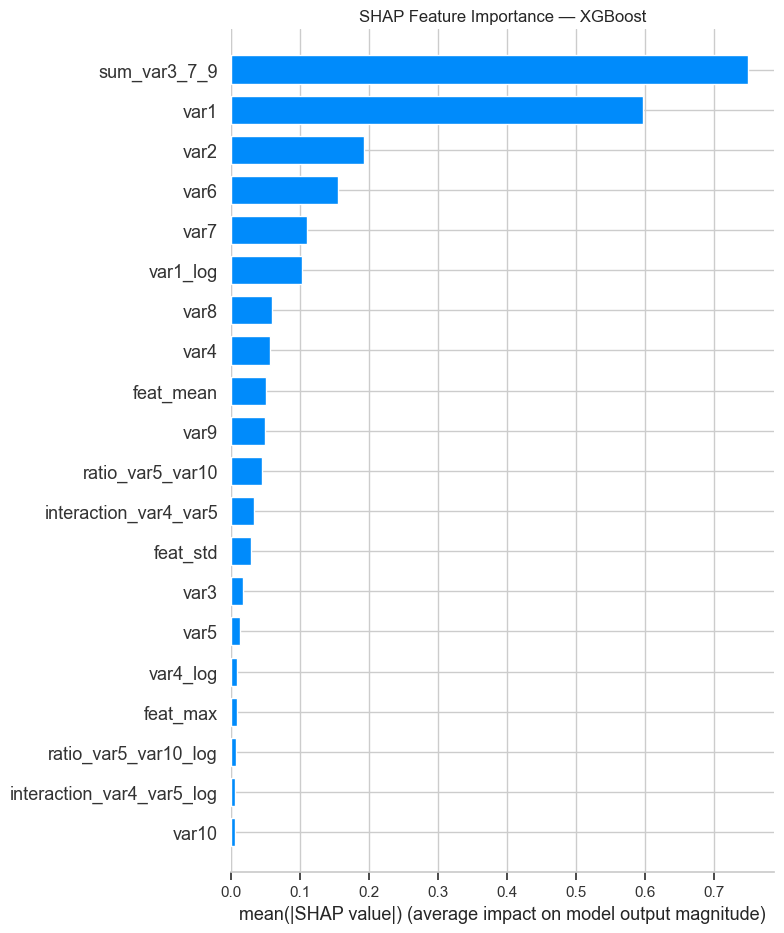

In [29]:
# ── Summary plot — importance globale ────────────────────────────────────────
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=False)
plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()
plt.show()


**Observations :** la variable agrégée `sum_var3_7_9` montre une contribution forte dans les prédictions du modèle. À l’inverse, certaines variables comme `has_anomalous_peak` ou `is_var5_missing` affichent des valeurs de Shapley extrêmement faibles, ce qui suggère un impact marginal. Une suppression de ces features pourrait alléger le modèle sans perte significative de performance.

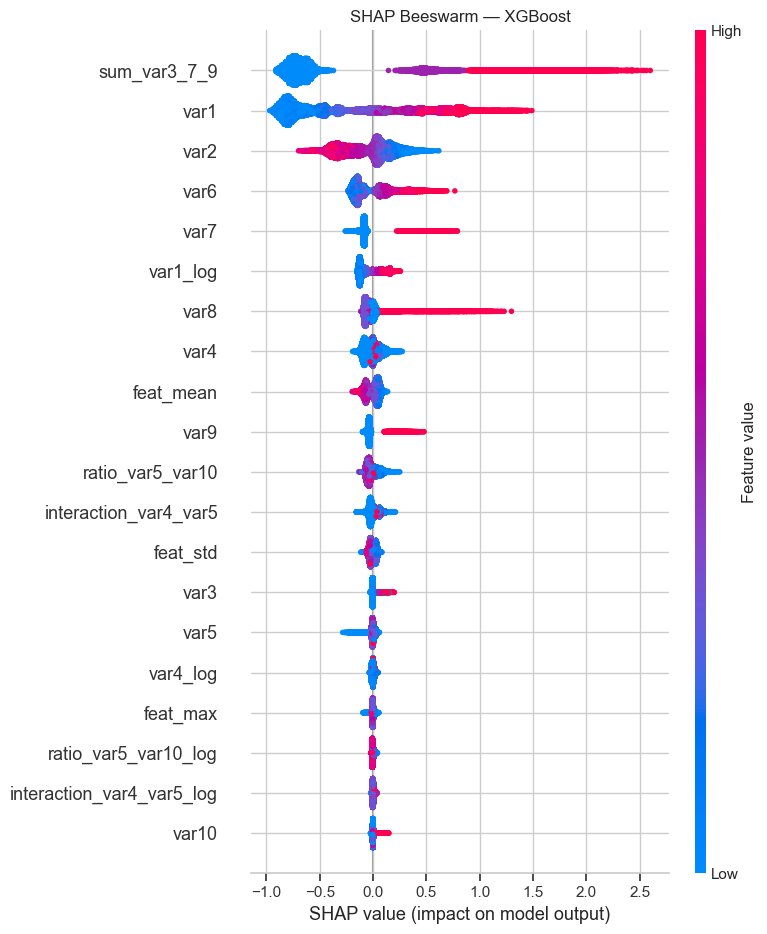

In [30]:
# ── Beeswarm plot ─────────────────────────────────────────────────────────────
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title("SHAP Beeswarm — XGBoost")
plt.tight_layout()
plt.show()

# Interprétation du SHAP Beeswarm Plot — XGBoost

---

## Features les plus influentes

**`sum_var3_7_9`** est de loin la feature la plus impactante. Les points rouges (valeurs élevées) s'étendent jusqu'à +2 de SHAP value, et les points bleus restent proches de 0 ou légèrement négatifs — la relation est **fortement positive et asymétrique** : ce sont les grandes valeurs de cette somme qui "tirent" la prédiction vers le haut, pas les petites qui la font descendre.

**`var1`** a un comportement similaire mais plus symétrique : valeurs élevées (rouge) augmentent la prédiction, valeurs faibles (bleu) la diminuent. C'est une relation **linéaire et robuste**.

**`var2`** présente un pattern intéressant : les points rouges sont à **gauche** (négatif) et les bleus à **droite** (positif), ce qui indique une **relation inverse** — une valeur élevée de var2 diminue la prédiction. À investiguer.

---

## Features à impact modéré

`var1_log`, `var6`, `var7`, `var5`, `var9`, `var8` ont des impacts visibles mais bien plus contenus (SHAP entre -0.5 et +0.5). Leurs distributions sont souvent très resserrées autour de 0, ce qui suggère qu'elles n'interviennent que dans des cas spécifiques.

---

## Features à très faible impact

`var3`, `interaction_var4_var5`, `var4_log`, `var5_log`, `interaction_var4_var5_log`, `ratio_var5_var10_log`, `var10`, `is_var5_missing`, `has_anomalous_peak` ont des SHAP values quasi nulles pour presque toutes les observations. Ces features **n'apportent presque rien** au modèle dans sa configuration actuelle.

---

## Suggestions de Feature Engineering

1. **Creuser `sum_var3_7_9`** — c'est la feature construite la plus puissante. Tester des variantes : moyenne, produit, ratio entre var3/var7/var9 individuellement pour voir si l'une d'elles porte l'essentiel du signal.

2. **Comprendre la relation inverse de `var2`** — est-ce un effet réel ou un artefact de corrélation avec `sum_var3_7_9` ? Tester une interaction `var1 * var2` ou `var1 / var2`.

3. **Supprimer les features mortes** — `is_var5_missing`, `has_anomalous_peak`, `var10`, `ratio_var5_var10_log` n'apportent rien. Les enlever simplifiera le modèle sans perte de performance, et réduira le risque de surapprentissage.

4. **Retravailler les interactions** — `interaction_var4_var5` et ses variantes log sont inefficaces. Si var4 et var5 ont un lien métier, explorer plutôt un **ratio** ou une **différence** plutôt qu'un produit.

5. **Explorer des transformations sur `var1`** — puisque `var1` et `var1_log` ont tous les deux un impact, cela suggère que la relation est non-linéaire. Tester `var1²` ou une discrétisation en quantiles pour capturer des effets de seuil.

In [31]:
# ── DataFrame des SHAP values ─────────────────────────────────────────────
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
print(f"Expected value (base rate) : {expected_value:.4f}")
print(shap_df.describe())

Expected value (base rate) : -2.6415
            var1       var2       var3       var4       var5       var6  \
count 45002.0000 45002.0000 45002.0000 45002.0000 45002.0000 45002.0000   
mean     -0.2660    -0.0510     0.0070    -0.0110    -0.0006    -0.0107   
std       0.5942     0.2276     0.0307     0.0680     0.0241     0.1794   
min      -0.9702    -0.6998    -0.0295    -0.1931    -0.2853    -0.2368   
25%      -0.7783    -0.2577    -0.0076    -0.0689    -0.0070    -0.1568   
50%      -0.5055     0.0107    -0.0048    -0.0144    -0.0006    -0.0897   
75%       0.2686     0.1209    -0.0016     0.0328     0.0092     0.1076   
max       1.4875     0.6158     0.1985     0.2735     0.0591     0.7657   

            var7       var8       var9      var10  is_var5_missing  \
count 45002.0000 45002.0000 45002.0000 45002.0000       45002.0000   
mean     -0.0645    -0.0132    -0.0258    -0.0004          -0.0005   
std       0.1213     0.1147     0.0623     0.0107           0.0037   
min    

## On affiche en 2D les margins 
Servirait a repérer des tendances intéressantes chez les features à faible impact, qui justifierait le fait de ne pas les supprimer 

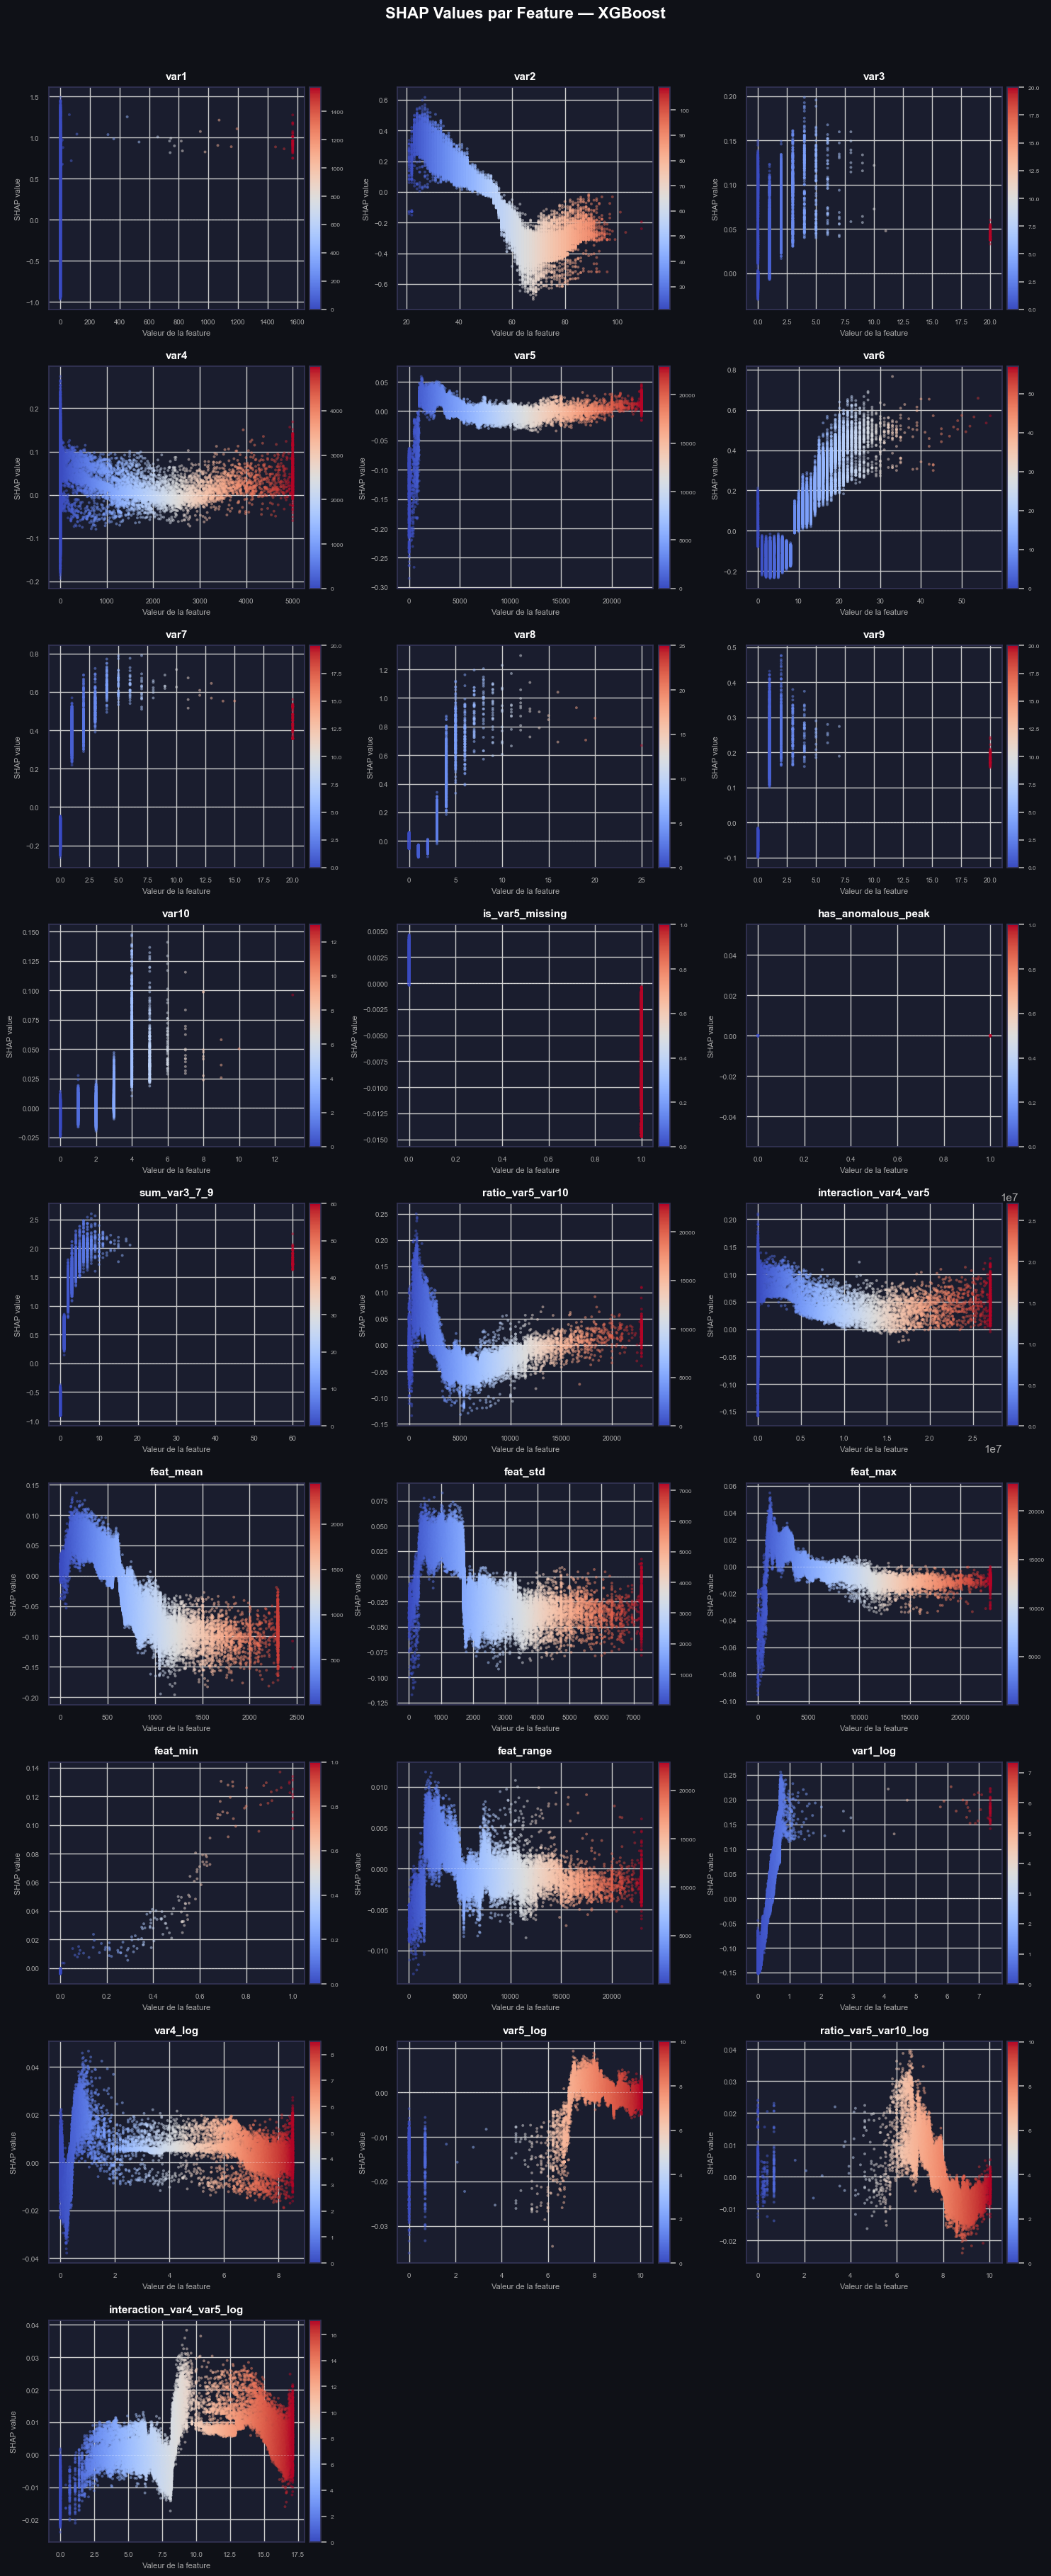

In [32]:
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

features = X_test.columns.tolist()
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
fig.patch.set_facecolor("#0f1117")
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    ax.set_facecolor("#1a1d2e")

    feat_vals = X_test[feature].values
    shap_vals = shap_df[feature].values

    # Couleur selon la valeur de la feature (bleu → rouge)
    norm = plt.Normalize(feat_vals.min(), feat_vals.max())
    colors = plt.cm.coolwarm(norm(feat_vals))

    ax.scatter(feat_vals, shap_vals, c=colors, alpha=0.5, s=8, linewidths=0)
    ax.axhline(0, color="white", linewidth=0.6, linestyle="--", alpha=0.4)

    # Style
    ax.set_title(feature, color="white", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Valeur de la feature", color="#aaaaaa", fontsize=8)
    ax.set_ylabel("SHAP value", color="#aaaaaa", fontsize=8)
    ax.tick_params(colors="#aaaaaa", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333355")

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
    cbar.ax.tick_params(colors="#aaaaaa", labelsize=6)
    cbar.outline.set_edgecolor("#333355")

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("SHAP Values par Feature — XGBoost", color="white",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

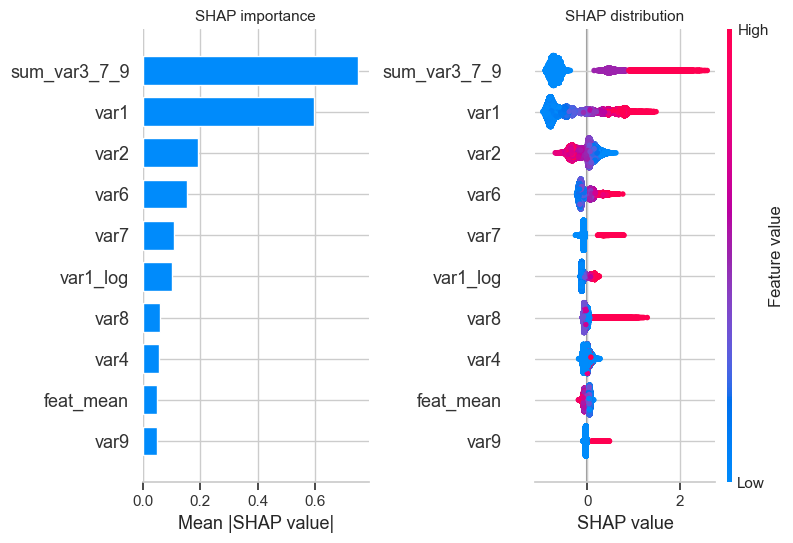

In [41]:
import matplotlib.pyplot as plt
import shap

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9
})

n_features = X_test.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(axes[0])
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=10,
    show=False
)
axes[0].set_title("SHAP importance")
axes[0].set_xlabel("Mean |SHAP value|")

plt.sca(axes[1])
shap.summary_plot(
    shap_values,
    X_test,
    max_display=10,
    show=False
)
axes[1].set_title("SHAP distribution")
axes[1].set_xlabel("SHAP value")

plt.tight_layout()
plt.savefig("shap_combined.png", dpi=400, bbox_inches="tight")
plt.show()